In [14]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import math

import copy
import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

#from common.model.cnn_simple import CIFAR10ReLU
from common.const import DATASET_PATH
from common.util import *
from common.meta import MetaData
from common.optimise_v3 import NetLineStepProcessor
#from common.optimise import OptimiserEtaSoftmaxArmihoNorm2Base, OptimiserEtaSoftmaxArmihoNorm1Base, reduce_to_active

from torchvision.datasets import CIFAR100
from torchvision import transforms

import logging

In [15]:
logging.basicConfig(filename="log_convcrity_cifar100_epochsd_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")


#### CIFAR100 dataset

In [16]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR100(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR100(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [17]:
BATCH_SIZE = 128 #32 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [18]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 100 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

#### Compare optimisers

In [19]:
def print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_ADAM['test_loss'], color='g', alpha=.5, label='Adam')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Net-line')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='SGD')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_ADAM['test_accuracy'], color='g', alpha=.5, label='Adam')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Net-line')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='SGD')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same CNN architecture for different optimisers")

    plt.show()

#### Reference CNN

In [20]:
def make_model():
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(4096, 512),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
        nn.Linear(512, 100)
    )

    return model

In [21]:
#HISTORY_NORM1 = collections.defaultdict(list)
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)
HISTORY_ADAM = collections.defaultdict(list)


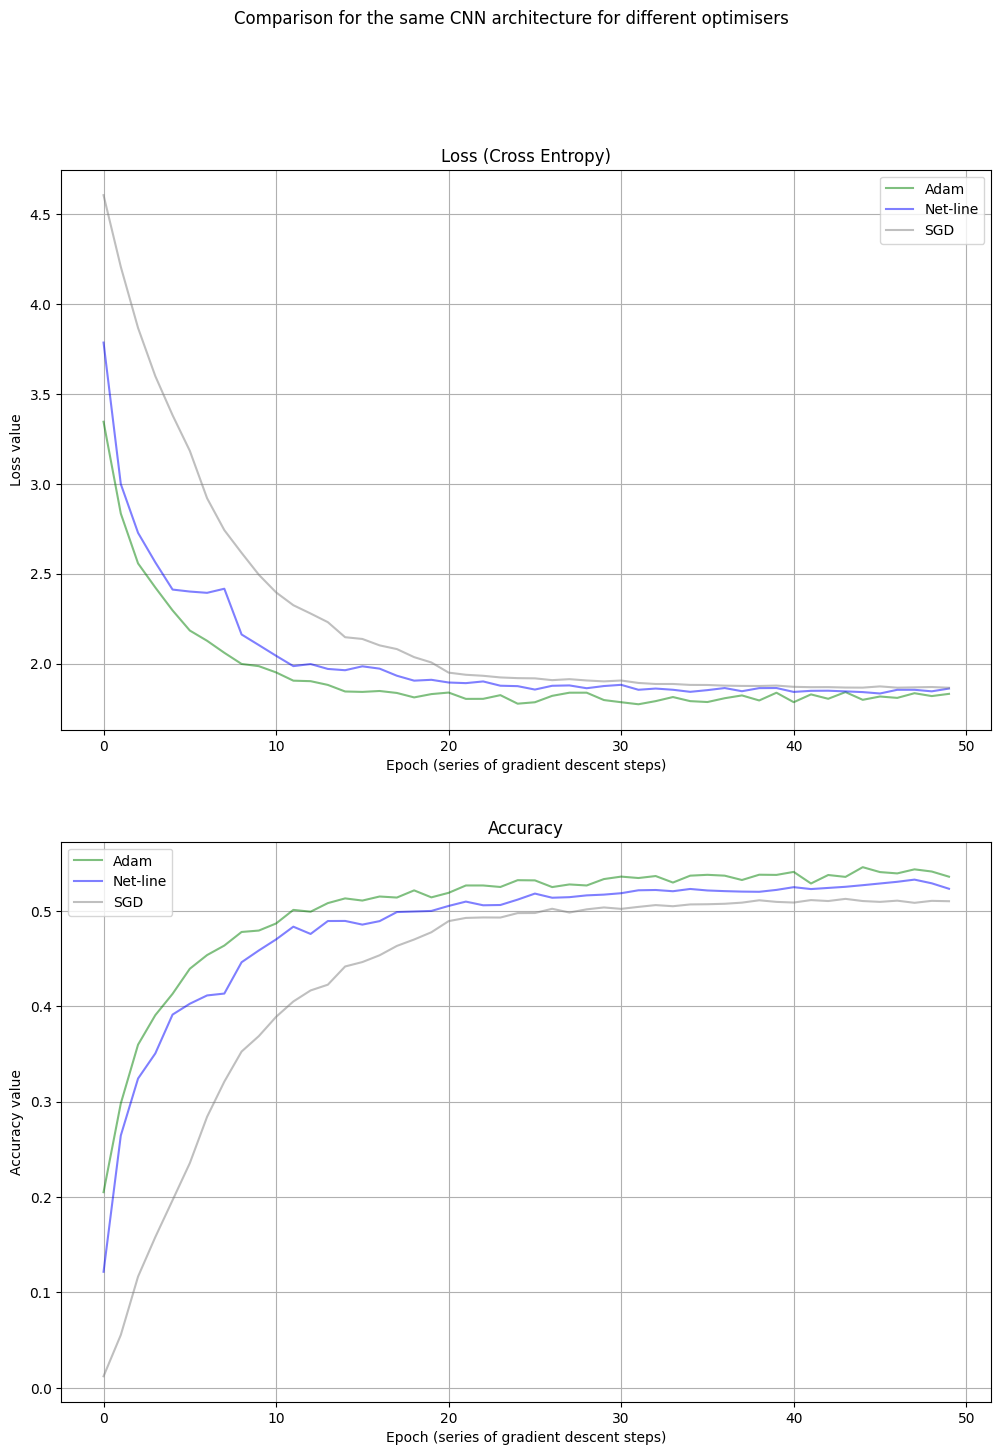

accuracy norm2=[0.1216376582278481, 0.2645371835443038, 0.32426819620253167, 0.3505735759493671, 0.39131724683544306, 0.4026898734177215, 0.41139240506329117, 0.41337025316455694, 0.4462025316455696, 0.458564082278481, 0.47013449367088606, 0.4834849683544304, 0.47587025316455694, 0.48941851265822783, 0.48951740506329117, 0.4856606012658228, 0.48931962025316456, 0.4988132911392405, 0.4994066455696203, 0.5, 0.5052412974683544, 0.5097903481012658, 0.5059335443037974, 0.5062302215189873, 0.5118670886075949, 0.5181962025316456, 0.5138449367088608, 0.5144382911392406, 0.516317246835443, 0.5171083860759493, 0.5185917721518988, 0.5216574367088608, 0.5219541139240507, 0.5206685126582279, 0.5230419303797469, 0.5214596518987342, 0.5207674050632911, 0.5202729430379747, 0.5200751582278481, 0.5220530063291139, 0.5249208860759493, 0.5229430379746836, 0.524129746835443, 0.5253164556962026, 0.5269976265822784, 0.5287776898734177, 0.530557753164557, 0.5328322784810127, 0.5289754746835443, 0.523239715189

In [22]:
def test_loop(testNet):
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

    return test_loss_meter.avg, test_accuracy_meter.avg


NUM_EPOCH = 50
meta = MetaData(output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE)

eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)

testNorm2S = copy.deepcopy(testOptfix)
stepProcessor = NetLineStepProcessor(testNorm2S, nn.CrossEntropyLoss(), meta, DEVICE)

testAdam = copy.deepcopy(testOptfix)
loss_adam = nn.CrossEntropyLoss()
optimizerAdam = optim.Adam(testAdam.parameters())

do_dropout, epoch_switch=False, 100
for epoch in range(NUM_EPOCH):
    iter=0
    train_eta2raw_plus_meter, train_eta2raw_minus_meter, train_eta2_meter, train_armiho2_meter, train_wolf2_meter\
          = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()

    loss_data = HISTORY_NORM2['test_loss']
    if len(loss_data) > 1 and ((loss_data[-2]-loss_data[-1])/loss_data[-1]) < 0.000001:
        do_dropout = True
    epoch_switch = min(epoch, epoch_switch) if do_dropout else epoch_switch
    
    lr = eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01

    stepProcessor.c1 = 0.0125
    stepProcessor.eta_max = 100* lr #if not do_dropout else lr
    stepProcessor.eta_min = 0.01* lr #if not do_dropout else lr
    stepProcessor.reducing_coeff = 1.0 if not do_dropout else 0.5 if epoch < 10 else 0.25 if epoch < 20 else 0.125
    stepProcessor.eta0 = 0.000_000_25
    stepProcessor.iter_max = 2
    stepProcessor.momentum_gradient_smoothing_coefficient = 10.0 #10.0
    
    stepProcessor.training_mode=do_dropout
    testNorm2S.train(False)
    step_params = {"estimation_type": 'analytic-norm2'} #if not do_dropout \
        #else {"estimation_type": 'analytic-norm2', "check_additional": False, 'check_armiho': False}

    optimizerFix.param_groups[0]['lr'] = lr
    testOptfix.train()

    testAdam.train(True)

    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##\n --==Epoch={}, iter={}==--".format(epoch, iter))
        logging.info("####Step with net-line norm2")
        step_result = stepProcessor.step(labels, images, momentum=0.9, nesterov=True, step_params=step_params)
        train_eta2_meter.update(step_result.eta)
        train_armiho2_meter.update(step_result.ck_armiho)
        train_wolf2_meter.update(step_result.ck_wolf)
        if step_result.eta_raw > 0.0:
            train_eta2raw_plus_meter.update(step_result.eta_raw)
        else:
            train_eta2raw_minus_meter.update(step_result.eta_raw)  

        logging.info("####Step with SGD-fix, eta={}".format(optimizerFix.param_groups[0]['lr']))
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

        logging.info("####Step with Adam-fix, eta={}".format(optimizerAdam.param_groups[0]['lr']))
        logitsAdam = testAdam.forward(images)
        lossAdam = loss_adam(logitsAdam, labels)
        optimizerAdam.zero_grad()
        lossAdam.backward()
        optimizerAdam.step()

    HISTORY_NORM2['train_eta'].append(train_eta2_meter.avg)
    HISTORY_NORM2['train_eta_raw_plus'].append(train_eta2raw_plus_meter.avg)
    HISTORY_NORM2['train_eta_raw_minus'].append(train_eta2raw_minus_meter.avg)
    HISTORY_NORM2['train_armiho'].append(train_armiho2_meter.avg)
    HISTORY_NORM2['train_wolf'].append(train_wolf2_meter.avg)

    testNorm2S.eval()
    testOptfix.eval()
    testAdam.eval()
    # testing loop
    netl, neta = test_loop(testNorm2S)
    HISTORY_NORM2['test_loss'].append(netl)
    HISTORY_NORM2['test_accuracy'].append(neta) 

    sgdl, sgda = test_loop(testOptfix)
    HISTORY_OPTFIX['test_loss'].append(sgdl)
    HISTORY_OPTFIX['test_accuracy'].append(sgda)

    adaml, adama = test_loop(testAdam)
    HISTORY_ADAM['test_loss'].append(adaml)
    HISTORY_ADAM['test_accuracy'].append(adama)    
    
    print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM)
    print("accuracy norm2={}, \naccuracy sgd-fix={}, \naccuracy adam-fix={}, \nswitch={}, reducing_coeff={}"\
          .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy'], HISTORY_ADAM['test_accuracy']\
                  , epoch_switch, stepProcessor.reducing_coeff))


In [23]:
HISTORY_NORM2['train_armiho']


[0.715831542290252,
 0.6098419700293705,
 0.5570240118578045,
 0.5345839564919844,
 0.5143169572678591,
 0.4944121831425754,
 0.4597802281667503,
 0.43241956099081047,
 0.7809639328942434,
 0.780919207463006,
 0.884514022196679,
 0.8880232981913205,
 0.8839026042168557,
 0.8839960222536144,
 0.887312100108114,
 0.8850036876449919,
 0.8820902030013897,
 0.8850015877554462,
 0.8859325211650277,
 0.8868086010127678,
 0.940633300531585,
 0.9410031279914883,
 0.9271698205682999,
 0.942325910469634,
 0.9424602676325171,
 0.942699078489795,
 0.940519245394152,
 0.94165645994231,
 0.9420604468614456,
 0.9429052468270535,
 0.9426297055203763,
 0.9415295270503253,
 0.941809318006812,
 0.9427778023085467,
 0.9436945162649079,
 0.9419728527221424,
 0.9432391763587888,
 0.9442633787093997,
 0.9439228795803188,
 0.9438977284843342,
 0.9492235994023045,
 0.9478866690903464,
 0.9498968631306315,
 0.9485663435196853,
 0.9489054974092004,
 0.9488182860328275,
 0.9488087560000449,
 0.9494487817302786,
 0

In [24]:
HISTORY_NORM2['train_wolf']

[0.5304896612047256,
 0.3888239646342693,
 0.3539170846618738,
 0.3381495412018103,
 0.32220023683801274,
 0.3077339058431807,
 0.2796052772963347,
 0.26199702630747096,
 0.6137755677842777,
 0.6151364021946922,
 0.7859765948451691,
 0.7912408946959355,
 0.784294940554,
 0.7849024914161443,
 0.7898485064592136,
 0.7864196841710231,
 0.7885564919335636,
 0.7872215503829347,
 0.7873616289162104,
 0.7899386988975214,
 0.8844598712091822,
 0.88505896427772,
 0.8857748247860281,
 0.887525810556229,
 0.8878242668354873,
 0.8885834265592353,
 0.8847491255858043,
 0.886557766821965,
 0.887362387315453,
 0.8886939170537593,
 0.8882550828564941,
 0.8863032359970596,
 0.8869038352628903,
 0.8884048120592073,
 0.8902123136975777,
 0.8873074712428427,
 0.8896295617579529,
 0.8907614875686798,
 0.8905879262332111,
 0.8907663570743541,
 0.9003864279985242,
 0.8981560580717467,
 0.9014417599018937,
 0.8991523997418986,
 0.9000662305454096,
 0.8995234985543593,
 0.89950451259354,
 0.9009680204603048,
 

In [25]:
HISTORY_NORM2['train_eta']

[0.1810690315852807,
 0.08161072216011249,
 0.09209804437377972,
 0.09284923156627078,
 0.08648856960928251,
 0.08357536276930619,
 0.07787136151763772,
 0.07688589693242154,
 0.03097304141138905,
 0.030002260136011767,
 0.017943132463573867,
 0.017329221479149986,
 0.016895921423765448,
 0.016833880079701186,
 0.016397460232826802,
 0.016443105789921718,
 0.01620911481612481,
 0.016804411417064943,
 0.015314133702836966,
 0.015919102238711666,
 0.008706329169678097,
 0.008652873248820424,
 0.008666123769892876,
 0.00847679877451223,
 0.00859207033731258,
 0.008942935342101712,
 0.009079491084479282,
 0.008609730522712295,
 0.008706846009769426,
 0.008377597072490034,
 0.008343058881885492,
 0.00830161237421106,
 0.008445459530454303,
 0.008285519206634824,
 0.008442587076659186,
 0.00855123011875874,
 0.008586844966288698,
 0.008309504501254374,
 0.008106783577830139,
 0.008301232374927858,
 0.007654190857946598,
 0.0074457485404223825,
 0.007560281534399764,
 0.007430426413343681,
 0

In [26]:
HISTORY_NORM2['train_eta_raw']

[]